Figure 2G
(G) Degradation of DHX15 uniquely induces all classifications of cryptic splicing. Magnitude of cryptic splicing is quantified as the total number of unique cryptic splice junctions normalized to the number of known intron splicing events. Bar plot depicts fold change in cryptic splicing magnitude compared to DMSO treatment after 9hrs of target degradation (mean +/- SEM, n=3 biological replicates/condition, two-tailed unpaired Student’s t-test).

In [1]:
import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.patches import Patch
from natsort import os_sorted
from scipy.stats import sem


In [37]:
def get_sj(meta_df):
    filelist = []
    for i,row in meta_df.iterrows():
        filepath = '../../data/dtag_experiments/' + \
            anon_dict[row['Target']] + \
            '/sj_out/' + \
            row['Sample basename'].split('_Aligned')[0]
        filelist.append(glob.glob(filepath+'*')[0])
    return filelist


In [5]:
big_meta = pd.read_csv('../../data/dtag_experiments/metadata_anon.tsv',sep='\t')

big_meta.index = [i.split('_Aligned')[0] for i in big_meta['Sample basename'].values]

In [42]:
anon_dict_df = pd.read_csv('../../data/anon_data/anon_dict.tsv',sep='\t',header=None)
anon_dict = {row[0]:row[1] for i,row in anon_dict_df.iterrows()}

In [54]:
def get_uj_counts(filenam):
    test = pd.read_csv(filenam, sep='\t',low_memory=False)
    test_filt = test[test['unique'] >= 3]
    intronic = int(np.sum([i == 'intronic' for i in test_filt['class']]))
    match_5 = int(np.sum([i == 'matching 5' for i in test_filt['class']]))
    match_3 = int(np.sum([i == 'matching 3' for i in test_filt['class']]))
    ki = int(np.sum([i == 'known intron' for i in test_filt['class']]))
    
    return [ki, match_5, match_3, intronic]

def flatten(regular_list):
    return [item for sublist in regular_list for item in sublist]



In [48]:
big_filt = big_meta.loc[
    ((big_meta['Time value']>6) & (big_meta['Time value']<12))
].copy()

big_filt['code'] = big_filt['Target'] + '_' + \
    big_filt['Dosage value'].astype('str')

big_filt['filepath'] = get_sj(big_filt)

In [55]:
uj_counts = [get_uj_counts(i) for i in big_filt['filepath'].values]

uj_df = pd.DataFrame(uj_counts)
uj_df.columns = ['known intron', 'matching 5', 'matching 3', 'intronic']

uj_df.index = [i.split('_Aligned')[0] for i in big_filt['Sample basename'].values]

In [65]:
target_list = [
    'Gene6_0.0', 
    'Gene6_500.0', 
    'Gene2_0.0', 
    'Gene2_200.0',   
    'Gene8_0.0', 
    'Gene8_500.0', 
    'Gene5_0.0', 
    'Gene5_400.0', 
    'Gene7_0.0',
    'Gene7_400.0', 
    'Gene4_0.0', 
    'Gene4_250.0', 
    'Gene3_0.0',
    'Gene3_200.0', 
    'Gene1_0.0',
    'Gene1_250.0'
]

In [58]:
uj_ki_norm = uj_df.divide(uj_df.loc[:,'known intron'],axis=0)


In [97]:
bar_vals = []
error_vals = []
for i in target_list:
    inds = big_filt[big_filt['code'] == i].index
    control_inds = big_filt[big_filt['code'] == '_'.join([i.split('_')[0]]+['0.0'])].index
    norm_df = uj_ki_norm.loc[inds,:]/np.mean(uj_ki_norm.loc[control_inds,:],0)    
    bar_vals.append(np.mean(norm_df.loc[inds,:],0))
    error_vals.append(sem(norm_df.loc[inds,:],0))
    
bar_vals = pd.DataFrame(bar_vals)
error_vals = pd.DataFrame(error_vals)

bar_vals.index = target_list
error_vals.index = target_list
error_vals.columns = uj_df.columns

In [99]:
def make_uj_plot_no_ki_ax_2(code,ax,colornam):
    xvals = [
        0, 1,  
        3, 4,  
        6, 7, 
    ]

    bools = [code in i for i in target_list]
    yvals = flatten(bar_vals.iloc[:,1:].loc[bools].transpose().values)
    errors = flatten(error_vals.iloc[:,1:].loc[bools].transpose().values)

    ax.bar(
        xvals[0::2],
        yvals[0::2],
        yerr=errors[0::2],
        color='grey',
    )
    ax.bar(
        xvals[1::2],
        yvals[1::2],
        yerr=errors[1::2],
        color=colornam,
    )

    trt_vals = ['{:g}'.format(float(i.split('_')[1])) + ' nM' for i in np.array(target_list)[bools]]
    
    legend_elements = [
        Patch(
            facecolor='grey',
            label=trt_vals[0]
        ),
        Patch(
            facecolor=colornam,
            label=trt_vals[1] 
        ),
    ]

    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

    ax.legend(handles = legend_elements)

    xticks = [0.5, 3.5, 6.5]
    xtick_labs = ['cryptic 3ss', 'cryptic 5ss', 'intronic']
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labs,
                       fontsize=12,
                       rotation=40,
                       ha='right', 
                       rotation_mode='anchor')

    ax.set_title(code, fontsize=14)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

(0.0, 10.5)

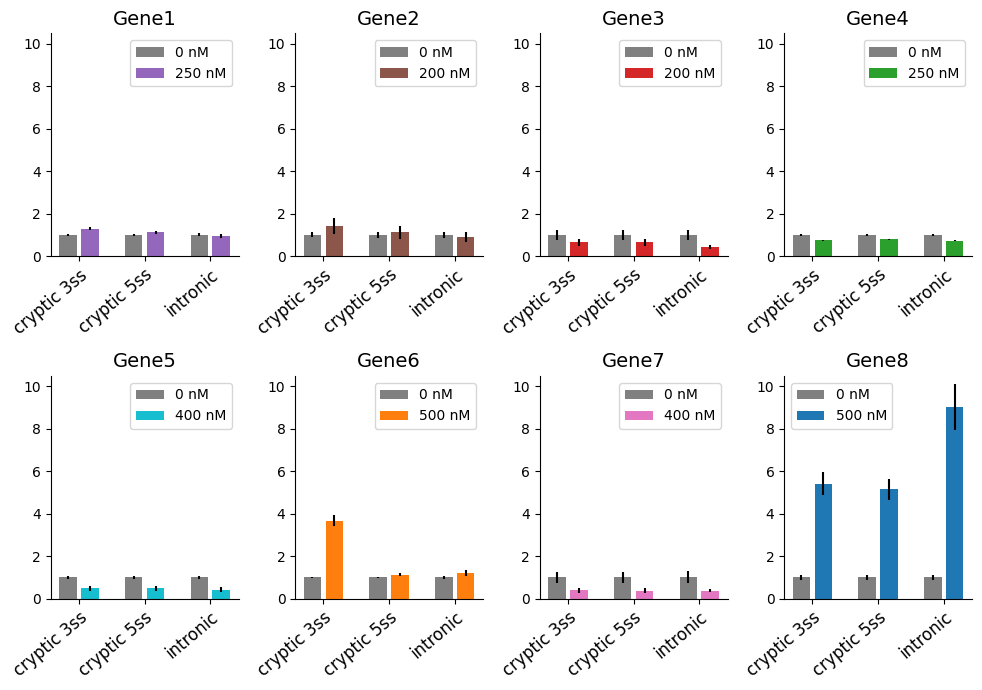

In [100]:
ylim = 10.5

fig,((ax1,ax2,ax3,ax4),(ax6,ax7,ax8,ax9)) = plt.subplots(2,4,figsize=(10,7))

make_uj_plot_no_ki_ax_2('Gene8',ax9,'tab:blue')
make_uj_plot_no_ki_ax_2('Gene6',ax7,'tab:orange')
make_uj_plot_no_ki_ax_2('Gene4',ax4,'tab:green')
make_uj_plot_no_ki_ax_2('Gene1',ax1,'tab:purple')
make_uj_plot_no_ki_ax_2('Gene3',ax3,'tab:red')
make_uj_plot_no_ki_ax_2('Gene2',ax2,'tab:brown')
make_uj_plot_no_ki_ax_2('Gene5',ax6,'tab:cyan')
make_uj_plot_no_ki_ax_2('Gene7',ax8,'tab:pink')

plt.tight_layout(w_pad=3)

ax1.set_ylim([0,ylim])
ax2.set_ylim([0,ylim])
ax3.set_ylim([0,ylim])
ax4.set_ylim([0,ylim])
ax6.set_ylim([0,ylim])
ax7.set_ylim([0,ylim])
ax8.set_ylim([0,ylim])
ax9.set_ylim([0,ylim])
